In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import spatial
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM

# Import your existing utilities, including the error injection function
from pdspl_utils.pairing import (
    normalize_data, 
    get_pairs_table_PDSPL, 
    get_kdtree_pairs,
    inject_observational_errors
)

def plot_scatter_vs_cumulative_neighbors(clean_table, sample_key, pairing_keys, cosmo, max_k=10):
    """
    Evaluates how the scatter in beta_E degrades as you allow pairs up to the k-th closest neighbor.
    Injects observational errors before pairing to simulate real data conditions.
    Also tracks and plots the cumulative number of pairs generated.
    """
    k_values = []
    scatters = []
    num_pairs_list = []
    
    # 1. Inject observational errors into the table
    print(f"Injecting observational errors for sample profile: {sample_key}")
    noisy_table = inject_observational_errors(clean_table, sample_key)
    
    # We loop from k=2 (which means 1 nearest neighbor) up to max_k + 1
    for k in range(2, max_k + 2):
        n_closest = k - 1 
        
        # 2. Get pairs up to the current threshold using the NOISY table
        pair_indices, _ = get_kdtree_pairs(noisy_table, pairing_keys, n_neighbors=k)
        
        # 3. Build PDSPL table using the CLEAN table (to get true physical scatter)
        pairs_table = get_pairs_table_PDSPL(clean_table, pair_indices, cosmo)
        
        # 4. Calculate Scatter and track pairs
        valid_mask = np.isfinite(pairs_table['rel_diff_beta_E'])
        scatter_beta_E = np.nanstd(pairs_table['rel_diff_beta_E'][valid_mask])
        n_pairs = len(pairs_table)
        
        k_values.append(n_closest)
        scatters.append(scatter_beta_E)
        num_pairs_list.append(n_pairs)
        
        print(f"Up to {n_closest}-th closest | Pairs generated: {n_pairs:<6} | Scatter in rel_diff_beta_E: {scatter_beta_E:.4f}")
        
    # Plotting
    fig, ax1 = plt.subplots(figsize=(9, 6))
    
    color_scatter = 'tab:red'
    color_pairs = 'tab:blue'
    
    # Primary Y-axis: Scatter
    ax1.set_xlabel("Pairs included up to the $k$-th nearest neighbor", fontsize=16)
    ax1.set_ylabel(r"$\sigma(\Delta \beta_E / \beta_E)$", fontsize=16, color=color_scatter)
    line1 = ax1.plot(k_values, scatters, marker='D', linestyle='-', color=color_scatter, linewidth=2.5, markersize=8, label='Scatter')
    ax1.tick_params(axis='y', labelcolor=color_scatter)
    ax1.set_xticks(k_values)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    # Secondary Y-axis: Number of Pairs
    ax2 = ax1.twinx()
    ax2.set_ylabel("Total Number of Pairs", fontsize=16, color=color_pairs)
    line2 = ax2.plot(k_values, num_pairs_list, marker='o', linestyle='--', color=color_pairs, linewidth=2.5, markersize=8, label='Num Pairs')
    ax2.tick_params(axis='y', labelcolor=color_pairs)
    
    # Thicken frames and ticks for both axes
    for ax in [ax1, ax2]:
        for spine in ax.spines.values(): spine.set_linewidth(2.0)
        ax.tick_params(axis='both', which='major', width=2.0, length=6, labelsize=12)
        
    # Combine legends
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=12, framealpha=0.9)
    
    plt.title(f"Scatter and Pair Count vs. Neighborhood Size ({sample_key})", fontsize=16, pad=15)
    plt.tight_layout()
    plt.show()
    
    return k_values, scatters, num_pairs_list

Injecting observational errors for sample profile: lsst_y10
Up to 1-th closest | Pairs generated: 85050  | Scatter in rel_diff_beta_E: 0.1537
Up to 2-th closest | Pairs generated: 159635 | Scatter in rel_diff_beta_E: 0.1601
Up to 3-th closest | Pairs generated: 231866 | Scatter in rel_diff_beta_E: 0.1655


Up to 4-th closest | Pairs generated: 302975 | Scatter in rel_diff_beta_E: 0.1698


Up to 5-th closest | Pairs generated: 373563 | Scatter in rel_diff_beta_E: 0.1735


Up to 6-th closest | Pairs generated: 444204 | Scatter in rel_diff_beta_E: 0.1760


Up to 7-th closest | Pairs generated: 514457 | Scatter in rel_diff_beta_E: 0.1783
Up to 8-th closest | Pairs generated: 584706 | Scatter in rel_diff_beta_E: 0.1805
Up to 9-th closest | Pairs generated: 655125 | Scatter in rel_diff_beta_E: 0.1824


Up to 10-th closest | Pairs generated: 725224 | Scatter in rel_diff_beta_E: 0.1843


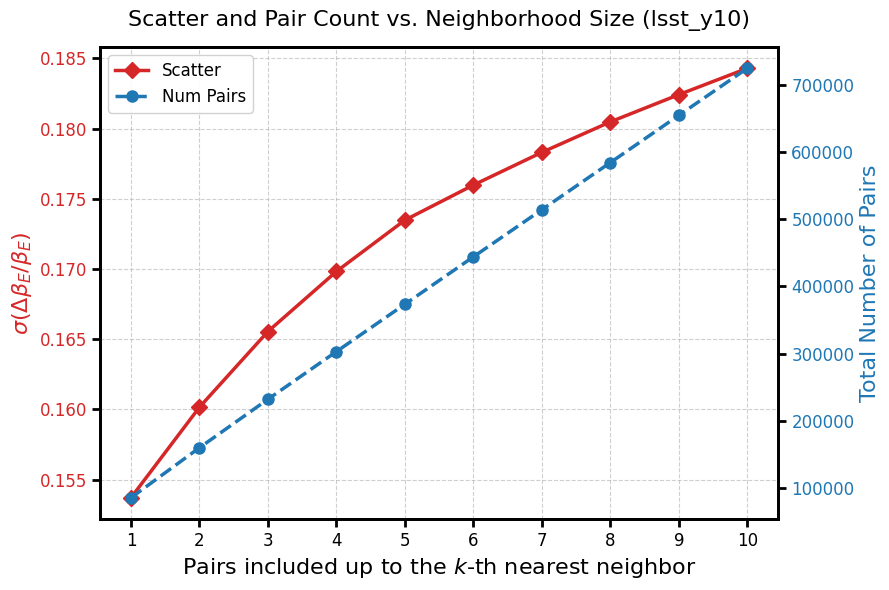

In [4]:
########################################################
# Load and preprocess the GGL data tables
########################################################
def preprocess_ggl_table(filepath):
    """Helper to apply standard transformations to raw GGL tables."""
    table = Table.read(filepath, format='fits')
    table['color_D_gr'] = table['mag_D_g'] - table['mag_D_r']
    table['color_D_ri'] = table['mag_D_r'] - table['mag_D_i']
    table['log_R_e_kpc'] = np.log10(table['R_e_kpc'])
    table['log_Sigma_half_Msun/pc2'] = np.log10(table['Sigma_half_Msun/pc2'])
    table['log_sigma_v_D'] = np.log10(table['sigma_v_D'])
    table.rename_column('size_D', 'R_e_arcsec')
    return table

GGL_table_LSST_Y10 = preprocess_ggl_table("../../data/GGL_Catalogs/GGL_20000.0_SQDEG_LSSTY10_SNR_20_seeing_0.5_contrast_02.fits")

# ==========================================
# Example Usage in your notebook:
# ==========================================
cosmo_true = FlatLambdaCDM(H0=70, Om0=0.3)
my_pairing_keys = ['z_D', 'R_e_arcsec', 'mag_D_i', 'color_D_gr', 'color_D_ri']
sample_profile = 'lsst_y10'

k_vals, scatter_vals, pair_counts = plot_scatter_vs_cumulative_neighbors(
    clean_table=GGL_table_LSST_Y10, 
    sample_key=sample_profile,
    pairing_keys=my_pairing_keys, 
    cosmo=cosmo_true, 
    max_k=10
)